In [1]:
!git clone https://github.com/addo561/stable-diffusion.git

Cloning into 'stable-diffusion'...
remote: Enumerating objects: 309, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 309 (delta 162), reused 236 (delta 103), pack-reused 0 (from 0)
Receiving objects: 100% (309/309), 2.47 MiB | 31.64 MiB/s, done.
Resolving deltas: 100% (162/162), done.


In [2]:
!mv stable-diffusion stable_diffusion

In [3]:
!touch /kaggle/working/stable_diffusion/__init__.py
!touch /kaggle/working/stable_diffusion/src/__init__.py

In [4]:
!pip  install -q  tqdm

In [5]:
%cd stable_diffusion

/kaggle/working/stable_diffusion


In [6]:
import requests
import torch
import numpy as np
from PIL import Image
from io import BytesIO
from matplotlib import pyplot as plt
from diffusers import UNet2DConditionModel
from diffusers import DDIMScheduler
from transformers import CLIPTokenizer,CLIPTextModel
from diffusers import AutoencoderKL
device = 'cuda' if torch.cuda.is_available()  else 'cpu'

img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"
def image(url):
    res =  requests.get(url)
    return Image.open(BytesIO(res.content)).convert('RGB')
mask_img =  image(mask_url).resize((512,512))
image_r = image(img_url).resize((512,512))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


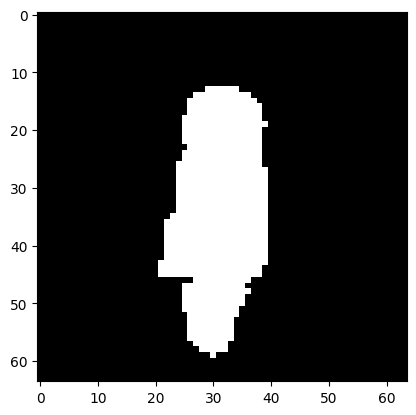

In [7]:
mask_image   =  mask_img.resize((64,64))
mask_image = torch.from_numpy((np.array(mask_image)[...,0]>5).astype(np.float32))
plt.imshow(mask_image.numpy(),cmap='gray')

In [8]:
scheduler = DDIMScheduler.from_pretrained('CompVis/stable-diffusion-v1-4', subfolder = 'scheduler')
model = UNet2DConditionModel.from_pretrained(
        "CompVis/stable-diffusion-v1-4",
        subfolder="unet"
    ).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

In [9]:
from pathlib  import  Path
from src.vae_clip import Clip_VAE
import  tqdm

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

CLIPTextModel LOAD REPORT from: CompVis/stable-diffusion-v1-4
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

loading: 30it [00:14,  2.00it/s]


Saved image to outputs/image_generated.png


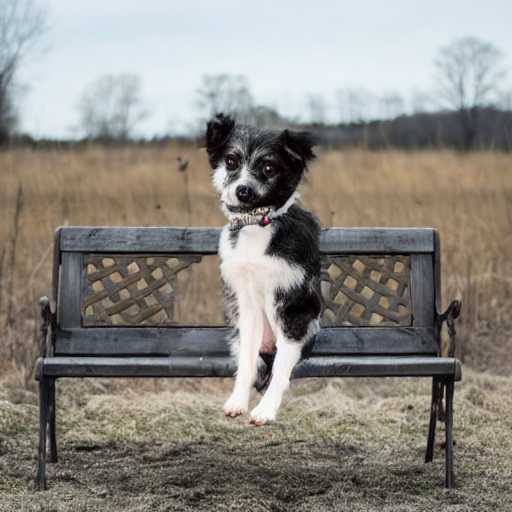

In [10]:
#things  i'll  need

"""
generated image + original photo
ONLY where                ONLY where
mask == 1                 mask == 0
"""
guidance = 8
num_steps = 30
prompt = "A  small dog, high resolution, sitting on the bench"
negative_prompt = "zoomed in, blurry, oversaturated, warped"

# text_embedding
encode_text = Clip_VAE(
                    model_name = 'clip',
                    device = device,
                    tokenizer = CLIPTokenizer,
                    text_encoder = CLIPTextModel
                    )

#  Decoder  vae
decoder_vae = Clip_VAE(
                    model_name = 'Vae_decode',
                    device = device,
                    Vae=AutoencoderKL
                    )
encoder_vae = Clip_VAE(
                    model_name = 'Vae_encode',
                    device = device,
                    Vae=AutoencoderKL
                    )
# image
image_original = torch.from_numpy(np.array(image_r).transpose(2,0,1)).float()/255.
image_original = 2 * image_original - 1 #[0,1]  to [-1,1]
image_original = image_original.unsqueeze(0).to(device)
mask_image = mask_image.to(device)
#timesteps
scheduler.set_timesteps(num_steps, device=device)
timesteps = scheduler.timesteps
with torch.no_grad():
    #text embedding
    cond = encode_text(prompt).to(device)
    cond_neg = encode_text(negative_prompt).to(device) 
    # get image  latents
    image_latent = encoder_vae(image_original)
    # random starting point
    latent  = torch.randn(1,4,64,64,device=device) # 1 batch
    latent *= scheduler.init_noise_sigma
    for i,t in tqdm.tqdm(enumerate(timesteps), desc='loading', colour='blue'):
        #scaling required by scheduler
        latent_input = scheduler.scale_model_input(latent,t)
        conditioned_pred = model(latent_input, t, cond).sample 
        unconditioned_pred = model(latent_input, t, cond_neg).sample
        noise_pred = unconditioned_pred + guidance * (conditioned_pred - unconditioned_pred)
        #compute prevoius sample
        latent = scheduler.step(noise_pred, t, latent).prev_sample
        #inpainting
        if i < len(timesteps)-1:# until last
            # add noise to image latent of prev timestep
            noise =  torch.randn_like(image_latent,device=device).float()
            background =  scheduler.add_noise(image_latent,noise,timesteps[i+1]) #adding noise cause latent at t was noisy too
            # white areas
            latent = latent * mask_image
            #black areas
            background =  background * (1-mask_image)
            #  combining genrated  latent and background  based on  mask
            latent += background
with  torch.no_grad():
    final_image = decoder_vae(latent)
final_image = final_image.squeeze()
final_image = (final_image.permute(1,2,0)  * 255.).to(torch.uint8).cpu().numpy()
final_image_PIL  = Image.fromarray(final_image)
path = Path('outputs')
path.mkdir(exist_ok=True)
img_path = path / 'image_generated.png'
plt.imsave(img_path, final_image)
print(f'Saved image to {img_path}')
final_image_PIL

In [11]:
%%writefile src/vae_clip.py
# i have to  make changes to the clip class module 
import torch
import torch.nn  as nn
  
class Clip_VAE(nn.Module):
    def __init__(self,
                model_name:  str,
                device,
                tokenizer = None,
                text_encoder = None,
                Vae = None 
                 ):
        """Module for clip tokenizer,text_encoder and vae decoder/encoder

        Attributes:
            text (str): specify component type(CLIP / VAE)
            device (cuda/cpu): device
            tokenizer : CLIPTokenizer, for input_ids or tokens
            text_encoder : CLIPTextModel, to  encode ids or  tokens to embeddings
            Vae : AutoencoderKL
        """
        super().__init__()
        self.model_name =  model_name
        self.device = device
        self.tokenizer  = tokenizer
        self.text_encoder = text_encoder
        self.Vae = Vae
        
        if self.model_name =='clip':
            self.get_tokens = self.tokenizer.from_pretrained('CompVis/stable-diffusion-v1-4',subfolder='tokenizer')
            self.get_embeddings = self.text_encoder.from_pretrained('CompVis/stable-diffusion-v1-4',subfolder='text_encoder').to(self.device)
            
        if  self.model_name == 'Vae_encode' or self.model_name == 'Vae_decode':
            self.latent_scaling_factor =  0.18215
            self.autoencoder = self.Vae.from_pretrained('CompVis/stable-diffusion-v1-4',subfolder='vae').to(device)
    @torch.inference_mode()        
    def forward(self,input : str | torch.Tensor)-> torch.Tensor:
        if self.model_name=='clip':
            input_ids = self.get_tokens([input],
                                       padding ='max_length',
                                       max_length = 77, #hardcoded as 77
                                       truncation=True, 
                                       return_tensors="pt",
                                       )['input_ids'] 
            input_ids_tensor =  input_ids.to(self.device)  
            text_embeddings =   self.get_embeddings(input_ids_tensor)['last_hidden_state']
            return  text_embeddings
        input = input.to(self.device)
        if  self.model_name == 'Vae_encode':
            # Extract the first element from the output object, then sample from it
            encoded = self.latent_scaling_factor * self.autoencoder.encode(input).latent_dist.sample()
            return encoded
        if  self.model_name == 'Vae_decode':
            decoded  = self.autoencoder.decode(input/self.latent_scaling_factor).sample
            return (decoded/2 + 0.5).clamp(0,1) # [-1,1] to [0,1]

Overwriting src/vae_clip.py
